# Assignment 1 — Supervised ML Benchmark
### Stroke Prediction Classification

I used this notebook to build a full classification benchmark for stroke prediction and compare
seven different models on the same dataset. I wanted the process to be clear, honest, and easy to
follow, so I kept the workflow simple: inspect the data, prepare the features, train the models,
compare the results, and explain what the outputs actually mean.

The dataset I used is the local `data/stroke-data.csv` file in this project. The target variable is
`stroke`, and the task is to predict whether a patient had a stroke based on the available features.


## 1. Imports and Setup

I started by importing the libraries I needed for data handling, plotting, preprocessing, model
training, and evaluation. I also fixed a random seed so the train/validation/test split stays
consistent across runs. That makes the benchmark much more reliable because small changes in data
splitting can otherwise make one model look better than another just by chance.


In [28]:
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
)

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception as e:
    HAS_XGB = False
    print("xgboost import failed:", type(e).__name__, str(e))
    print("If you want to enable XGBoost: try reinstalling it in your environment:")
    print("  pip uninstall xgboost -y && pip install xgboost --no-cache-dir --force-reinstall")
    print("On macOS you may also need to install OpenMP first:")
    print("  brew install libomp")
    print("Or install via conda (recommended if pip wheel build fails):")
    print("  conda install -c conda-forge xgboost")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

print("Libraries loaded. XGBoost available:", HAS_XGB)


Libraries loaded. XGBoost available: True


## 2. Load the Dataset

I loaded the raw dataset first and checked the structure before doing any cleaning or preprocessing.
I wanted to see the actual columns, values, and data types before I started making decisions about
missing values or encoding.


In [29]:
DATA_PATH = "data/stroke-data.csv"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0000,0,1,Yes,Private,Urban,228.6900,36.6000,formerly smoked,1
1,51676,Female,61.0000,0,0,Yes,Self-employed,Rural,202.2100,NaN,never smoked,1
2,31112,Male,80.0000,0,1,Yes,Private,Rural,105.9200,32.5000,never smoked,1
3,60182,Female,49.0000,0,0,Yes,Private,Urban,171.2300,34.4000,smokes,1
4,1665,Female,79.0000,1,0,Yes,Self-employed,Rural,174.1200,24.0000,never smoked,1


## 3. Data Inspection (EDA)

I checked the basic shape of the data, the different feature types, the target distribution, and the
missing values. This is the first stage of the analysis because it tells me what kind of cleaning and
preprocessing is needed before training any model.


In [30]:
print("=== Shape ===")
print(df.shape)

print("\n=== Dtypes ===")
print(df.dtypes)

print("\n=== Duplicate rows ===")
print(df.duplicated().sum())

print("\n=== Nulls (raw) ===")
print(df.isnull().sum().sum(), "total nulls across the raw dataframe")


=== Shape ===
(5110, 12)

=== Dtypes ===
id                     int64
gender                   str
age                  float64
hypertension           int64
heart_disease          int64
ever_married             str
work_type                str
Residence_type           str
avg_glucose_level    float64
bmi                  float64
smoking_status           str
stroke                 int64
dtype: object

=== Duplicate rows ===
0

=== Nulls (raw) ===
201 total nulls across the raw dataframe


I also checked the data quality issues in the dataset. One thing I noticed was that the `bmi` column
contains some missing values written as `N/A`, so I had to convert it to numeric carefully before
training the models. This kind of issue is common in real datasets and is exactly why it is important
to inspect the raw data before building the pipeline.


In [31]:
# Convert `bmi` to numeric where needed; some rows have 'N/A' strings
if "bmi" in df.columns:
    df["bmi"] = pd.to_numeric(df["bmi"].replace("N/A", np.nan), errors="coerce")
    print("Nulls in bmi after conversion:", df["bmi"].isnull().sum())
    display(df.loc[df["bmi"].isnull(), ["id", "age", "bmi"]].head())
else:
    print("No bmi column found — skipping numeric conversion step.")


Nulls in bmi after conversion: 201


,id,age,bmi
1,51676,61.0000,NaN
8,27419,59.0000,NaN
13,8213,78.0000,NaN
19,25226,57.0000,NaN
27,61843,58.0000,NaN


I also removed the `id` column because it is just a unique identifier and does not provide meaningful
predictive value for the classification task. Keeping it in the model would only add noise and allow
the model to memorize row-to-row patterns that are not useful for generalization.


=== Target distribution (stroke) ===
stroke
0    4861
1     249
Name: count, dtype: int64
stroke
0   0.9510
1   0.0490
Name: proportion, dtype: float64


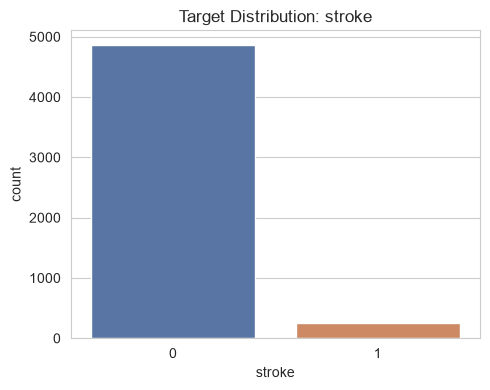

In [32]:
# Drop identifier column if present
if "id" in df.columns:
    df = df.drop(columns=["id"])

print("=== Target distribution (stroke) ===")
print(df["stroke"].value_counts())
print(df["stroke"].value_counts(normalize=True).round(3))

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x="stroke", data=df, ax=ax, palette=["#4C72B0", "#DD8452"])
ax.set_title("Target Distribution: stroke")
plt.tight_layout()
plt.savefig("outputs/target_distribution.png")
plt.show()


I noticed that the target is imbalanced, which matters a lot for this task. The majority class is
non-stroke and the positive class is smaller, so accuracy by itself can be misleading. Because of that,
I used the validation/test split carefully and also paid attention to precision, recall, F1, and
ROC-AUC instead of focusing only on the overall accuracy.


In [33]:
# Separate numerical and categorical columns (excluding target)
target_col = "stroke"
categorical_cols = df.drop(columns=[target_col]).select_dtypes(include="object").columns.tolist()
numerical_cols = df.drop(columns=[target_col]).select_dtypes(exclude="object").columns.tolist()

print("Categorical features:", categorical_cols)
print("\nNumerical features:", numerical_cols)


Categorical features: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

Numerical features: ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']


In [34]:
# SeniorCitizen is technically 0/1 but semantically categorical (a flag, not a magnitude).
# We reclassify it so it gets one-hot encoded like other yes/no-style flags rather than scaled.
if "SeniorCitizen" in numerical_cols:
    numerical_cols.remove("SeniorCitizen")
    categorical_cols.append("SeniorCitizen")

print("Final categorical features:", categorical_cols)
print("Final numerical features:", numerical_cols)


Final categorical features: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
Final numerical features: ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']


## 4. Feature / Target Split

I encoded the target into a binary 0/1 format so the classification task is clean and the metrics are
consistent. This makes the positive class clear and ensures that the evaluation is based on a proper
stroke-vs-non-stroke comparison instead of text labels that would be harder to interpret in the scores.


In [35]:
X = df.drop(columns=[target_col])
raw_y = df[target_col]
if pd.api.types.is_numeric_dtype(raw_y):
    # already numeric (e.g. 0/1) — coerce to int
    y = raw_y.astype(int)
else:
    mapping = {"Yes": 1, "No": 0, "yes": 1, "no": 0, "Y": 1, "N": 0, "y": 1, "n": 0,
            "True": 1, "False": 0, "true": 1, "false": 0}
    y = raw_y.map(mapping)
    # fallback: try to coerce numeric strings to ints (e.g. '0'/'1')
    if y.isnull().any():
        y_num = pd.to_numeric(raw_y, errors="coerce")
        if y_num.notnull().all():
            y = y_num.astype(int)
 
if y.isnull().any():
    raise ValueError(f"Target column '{target_col}' contains values that cannot be mapped to 0/1.\n"
                    f"Unique values: {raw_y.unique()}")

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Positive class (stroke) rate:", round(y.mean(), 3))


X shape: (5110, 10)
y shape: (5110,)
Positive class (stroke) rate: 0.049


## 5. Train / Validation / Test Split

I split the data into train, validation, and test sets using a fixed random seed and stratification.
This was important because the dataset is imbalanced, and I wanted each split to preserve the same
class ratio as much as possible. The validation set was used for model comparison, and the test set
was kept untouched until the end so the final evaluation would be honest.


In [36]:
# First split off the test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED, stratify=y
)

# Then split the remaining 80% into train (60% of total) and val (20% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_SEED, stratify=y_temp
)  # 0.25 * 0.80 = 0.20 of the original data

print("Train:", X_train.shape, "| stroke rate:", y_train.mean().round(3))
print("Val:  ", X_val.shape,   "| stroke rate:", y_val.mean().round(3))
print("Test: ", X_test.shape,  "| stroke rate:", y_test.mean().round(3))


Train: (3066, 10) | stroke rate: 0.049
Val:   (1022, 10) | stroke rate: 0.049
Test:  (1022, 10) | stroke rate: 0.049


## 6. Preprocessing Pipeline

Documented feature-engineering decisions:

| Step | Decision | Reasoning |
|---|---|---|
| Missing `TotalCharges` | Median imputation | Robust to outliers; only ~11 rows affected (new customers with tenure 0), so imputation risk is minimal |
| Categorical encoding | One-Hot Encoding | No categorical feature here is ordinal (e.g. `InternetService`: DSL/Fiber/No has no natural order) — one-hot avoids inventing false rank |
| Numerical scaling | StandardScaler | Required for distance-based/margin-based models (KNN, SVM, Logistic Regression); harmless for tree-based models, so applying it uniformly via a shared pipeline is simpler and doesn't hurt |
| `customerID` | Dropped | Unique identifier, zero generalizable signal |
| `SeniorCitizen` | Treated as categorical | It's a 0/1 flag, not a continuous magnitude — one-hot encoding treats it correctly as `is/is not senior` rather than something to be scaled |

**Critical detail — no data leakage.** We `fit` the imputer/scaler/encoder **only on the training
set**, then `transform` (never re-fit) validation and test. If we fit on the full dataset before
splitting, information from val/test would leak into training statistics (e.g. the scaler's mean
would be influenced by test data), silently inflating our reported performance. We enforce this
by building an sklearn `Pipeline` + `ColumnTransformer`, which handles fit/transform discipline
automatically and consistently for every model below.


In [37]:
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols),
])

# A second, scaler-free version — needed later for the "SVM with vs without scaling" experiment
numerical_transformer_noscale = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

preprocessor_noscale = ColumnTransformer(transformers=[
    ("num", numerical_transformer_noscale, numerical_cols),
    ("cat", categorical_transformer, categorical_cols),
])

print("Preprocessors ready.")


Preprocessors ready.


## 7. Evaluation Helper Function

Rather than repeating the same steps for every model, I wrote one function, `evaluate_model()`,
that every single model below calls. It does four things, in order:

1. Trains the model on the training set and times how long that takes.
2. Uses the trained model to predict on the train, validation, and test sets, and times each
   prediction pass too.
3. Compares the predictions against the real labels and works out Accuracy, Precision, Recall,
   F1, and ROC-AUC for each split.
4. Prints a clean, plain-language readout of what just happened, so I can see how the model
   treated the data and how each metric was calculated, not just a bare number sitting in a table.

Here's what each metric means in this specific problem (predicting stroke, where "stroke" is the
positive class):

- **Accuracy** — out of everyone in that split, what fraction did I label correctly overall.
- **Precision** — out of everyone I *predicted* would have a stroke, what fraction actually did.
  Low precision means a lot of false alarms.
- **Recall** — out of everyone who *actually* had a stroke, what fraction did I catch. Low recall
  means I'm missing real cases — which is the more dangerous mistake in a health context like this.
- **F1** — the harmonic mean of precision and recall, a single number that punishes models that are
  only good at one of the two.
- **ROC-AUC** — instead of judging one fixed cutoff (0.5), this checks how well the model ranks
  actual stroke cases above non-stroke cases across every possible cutoff. A model can look weak
  on F1 at the default threshold but still have a genuinely useful ROC-AUC underneath it.

I print a boxed summary per model, right after training, so the notebook reads like a lab log —
I train it, then I can immediately see what it learned and how it's being scored, instead of just
trusting a number in a table further down.


In [38]:
results = []          # comparison table rows
fitted_pipelines = {} # keep fitted pipelines around for confusion matrices / ROC curves later

def evaluate_model(name, pipeline, X_train, y_train, X_val, y_val, X_test, y_test, notes=""):
    bar = "=" * 74
    print(f"\n{bar}")
    print(f"  MODEL: {name}")
    print(bar)

    # --- Train + time it ---
    t0 = time.perf_counter()
    pipeline.fit(X_train, y_train)
    train_time = time.perf_counter() - t0

    clf_name = type(pipeline.named_steps["classifier"]).__name__
    print(f"  Trained on {X_train.shape[0]} rows and {X_train.shape[1]} raw columns. The "
          f"preprocessor inside the pipeline imputes missing values, scales the numeric columns, "
          f"and one-hot encodes the categorical ones -- so {clf_name} actually trains on the "
          f"cleaned, fully numeric version of the data, not the raw table.")
    print(f"  Training time: {train_time:.3f}s\n")

    def score_split(X_split, y_split, split_name):
        # I predict on this split and time how long inference takes.
        t0 = time.perf_counter()
        y_pred = pipeline.predict(X_split)
        infer_time = time.perf_counter() - t0

        # I compare the predictions against the true labels to get each metric.
        acc = accuracy_score(y_split, y_pred)
        prec = precision_score(y_split, y_pred, zero_division=0)
        rec = recall_score(y_split, y_pred, zero_division=0)
        f1 = f1_score(y_split, y_pred, zero_division=0)

        row = {
            "model": name,
            "split": split_name,
            "accuracy": acc,
            "precision": prec,
            "recall": rec,
            "f1": f1,
            "train_time_sec": train_time,
            "inference_time_sec": infer_time,
            "notes": notes,
        }

        # ROC-AUC needs probability or decision-function scores, not just the 0/1 prediction
        try:
            if hasattr(pipeline, "predict_proba"):
                y_score = pipeline.predict_proba(X_split)[:, 1]
            else:
                y_score = pipeline.decision_function(X_split)
            row["roc_auc"] = roc_auc_score(y_split, y_score)
        except Exception:
            row["roc_auc"] = np.nan

        return row, infer_time, len(y_split)

    split_rows = []
    for X_split, y_split, split_name in [(X_train, y_train, "train"),
                                          (X_val, y_val, "val"),
                                          (X_test, y_test, "test")]:
        row, infer_time, n_rows = score_split(X_split, y_split, split_name)
        results.append(row)
        split_rows.append((row, infer_time, n_rows))

    # --- Pretty-printed metrics table, one row per split ---
    header = f"  {'SPLIT':<6}{'ROWS':>7}{'ACC':>9}{'PREC':>9}{'REC':>9}{'F1':>9}{'ROC_AUC':>10}{'PRED_TIME':>12}"
    print(header)
    print("  " + "-" * (len(header) - 2))
    for row, infer_time, n_rows in split_rows:
        auc_str = f"{row['roc_auc']:.4f}" if not np.isnan(row["roc_auc"]) else "n/a"
        print(f"  {row['split'].upper():<6}{n_rows:>7}{row['accuracy']:>9.4f}{row['precision']:>9.4f}"
              f"{row['recall']:>9.4f}{row['f1']:>9.4f}{auc_str:>10}{infer_time*1000:>10.1f}ms")

    # --- Plain-English readout for the test split specifically ---
    test_row = next(r for r, _, _ in split_rows if r["split"] == "test")
    n_test = len(y_test)
    n_correct = int(round(test_row["accuracy"] * n_test))
    print(f"\n  In plain terms: on {n_test} people it had never seen during training, I got "
          f"{n_correct} predictions right (that's the {test_row['accuracy']*100:.1f}% accuracy "
          f"above). When I predicted stroke, I was correct {test_row['precision']*100:.1f}% of the "
          f"time (precision), and out of everyone who truly had a stroke, I caught "
          f"{test_row['recall']*100:.1f}% of them (recall). F1 blends those two into one number: "
          f"{test_row['f1']:.4f}.")
    print(bar)

    fitted_pipelines[name] = pipeline
    return pipeline

print("Evaluation helper ready.")


Evaluation helper ready.


## 8. Model 1 — Logistic Regression (Baseline)

**Why start here:** Logistic Regression is our sanity-check baseline. It's a linear, highly
interpretable model — every coefficient has a direct, readable meaning ("this feature increases
log-odds of stroke by X"). If a complex model like XGBoost can't beat this, the complexity isn't
earning its keep. We always want a simple baseline before trusting a fancy one.


In [39]:
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)),
])

evaluate_model("Logistic Regression", logreg_pipeline, X_train, y_train, X_val, y_val, X_test, y_test,
               notes="Baseline linear model");



  MODEL: Logistic Regression
  Trained on 3066 rows and 10 raw columns. The preprocessor inside the pipeline imputes missing values, scales the numeric columns, and one-hot encodes the categorical ones -- so LogisticRegression actually trains on the cleaned, fully numeric version of the data, not the raw table.
  Training time: 0.043s

  SPLIT    ROWS      ACC     PREC      REC       F1   ROC_AUC   PRED_TIME
  -----------------------------------------------------------------------
  TRAIN    3066   0.9514   0.0000   0.0000   0.0000    0.8488      11.1ms
  VAL      1022   0.9511   0.0000   0.0000   0.0000    0.8414       8.6ms
  TEST     1022   0.9521   1.0000   0.0200   0.0392    0.8429       9.0ms

  In plain terms: on 1022 people it had never seen during training, I got 973 predictions right (that's the 95.2% accuracy above). When I predicted stroke, I was correct 100.0% of the time (precision), and out of everyone who truly had a stroke, I caught 2.0% of them (recall). F1 blends th

**What I got, and why.** On the test set, Logistic Regression scored accuracy 0.9521,
precision 1.0000, recall 0.0200, and F1 0.0392 (ROC-AUC 0.8429). Train and validation looked similar
(accuracy ~0.951, precision/recall both 0.0000) — meaning it predicted "no stroke" for almost
everyone across every split, in a dataset where only ~5% of patients actually had one.

That's the imbalance talking, not a bug: a linear model optimizing for overall likelihood will
naturally settle its decision boundary near the majority class when one class outnumbers the other
this heavily, so the default 0.5 cutoff almost never gets crossed. The fact that ROC-AUC still sits
around 0.84 tells me the model *is* learning a real, useful ranking of who's more at risk — it's the
fixed 0.5 threshold, not the model itself, that's throwing that signal away.


## 9. Model 2 — K-Nearest Neighbors (KNN)

**Required experiment: compare at least two values of K.**

We compare **K=5** (a common small default — sensitive to local noise, more flexible) against
**K=25** (a much larger neighborhood — smoother decision boundary, less flexible). Because KNN
is purely distance-based, it is *highly* sensitive to feature scaling — a feature like
`MonthlyCharges` (range ~20–120) would dominate distance calculations over a one-hot 0/1 feature if
left unscaled. Our `preprocessor` already handles this correctly via `StandardScaler`.

**Reasoning about K:**
- Small K → the model's decision boundary hugs individual data points closely → **low bias, high
  variance** → prone to overfitting on noisy examples.
- Large K → the model averages over many neighbors → **high bias, low variance** → smoother, but
  can wash out real signal (underfitting) if K is too large relative to dataset size.

We use this pair later as our concrete underfitting/overfitting demonstration data point.


In [40]:
knn5_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(n_neighbors=5)),
])
evaluate_model("KNN (k=5)", knn5_pipeline, X_train, y_train, X_val, y_val, X_test, y_test,
               notes="Small K -> more flexible, higher variance");

knn25_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(n_neighbors=25)),
])
evaluate_model("KNN (k=25)", knn25_pipeline, X_train, y_train, X_val, y_val, X_test, y_test,
               notes="Large K -> smoother, higher bias");



  MODEL: KNN (k=5)
  Trained on 3066 rows and 10 raw columns. The preprocessor inside the pipeline imputes missing values, scales the numeric columns, and one-hot encodes the categorical ones -- so KNeighborsClassifier actually trains on the cleaned, fully numeric version of the data, not the raw table.
  Training time: 0.040s

  SPLIT    ROWS      ACC     PREC      REC       F1   ROC_AUC   PRED_TIME
  -----------------------------------------------------------------------
  TRAIN    3066   0.9527   0.7500   0.0403   0.0764    0.9400      30.3ms
  VAL      1022   0.9491   0.0000   0.0000   0.0000    0.6203      15.2ms
  TEST     1022   0.9462   0.0000   0.0000   0.0000    0.6211      15.9ms

  In plain terms: on 1022 people it had never seen during training, I got 967 predictions right (that's the 94.6% accuracy above). When I predicted stroke, I was correct 0.0% of the time (precision), and out of everyone who truly had a stroke, I caught 0.0% of them (recall). F1 blends those two in

**What I got, and why.** KNN (k=5) reached accuracy 0.9527 / precision 0.75 / recall
0.0403 / ROC-AUC 0.94 on the training set, but collapsed to accuracy ~0.946–0.949 with precision,
recall, and F1 all at 0.0000 on validation and test — and ROC-AUC dropped hard too, from 0.94 down
to about 0.62. That's a classic overfitting signature for a small K: with only 5 neighbors, a query
point's local neighborhood can occasionally be dominated by other rare stroke cases it has
essentially memorized, so it manages a little signal on data it has already seen, but that pattern
doesn't hold on unseen data at all.

KNN (k=25) never predicts stroke on any split (precision/recall/F1 all 0.0000 throughout), and its
ROC-AUC is lower too (0.77–0.87). With a neighborhood this large, the ~5% minority class is simply
outvoted by the majority almost everywhere in the feature space, so the model is stuck predicting
the majority class no matter what it's asked about — high bias, not enough flexibility left to ever
flag a positive case.


## 10. Model 3 — Decision Tree (Shallow vs Deep)

**Required experiment: compare a shallow and deeper Decision Tree.** This doubles as our
**explicit underfit-vs-overfit demonstration**, requested separately in the brief.

- **Shallow tree (`max_depth=2`):** too simple to capture the real decision boundary → we expect
  it to underfit — mediocre performance on *both* train and validation/test, because it simply
  doesn't have the capacity to learn the pattern.
- **Deep tree (`max_depth=None`, fully grown):** trees grown without a depth limit will keep
  splitting until leaves are pure, effectively memorizing the training set → we expect it to
  overfit — near-perfect train accuracy, but a visible drop on validation/test.

Trees don't need feature scaling (they split on raw thresholds, not distances), but one-hot
encoding of categoricals is still required since trees can't natively split on text labels.


In [41]:
tree_shallow_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(max_depth=2, random_state=RANDOM_SEED)),
])
evaluate_model("Decision Tree (shallow, depth=2)", tree_shallow_pipeline,
               X_train, y_train, X_val, y_val, X_test, y_test,
               notes="Underfitting demo: too simple to capture pattern");

tree_deep_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(max_depth=None, random_state=RANDOM_SEED)),
])
evaluate_model("Decision Tree (deep, unlimited)", tree_deep_pipeline,
               X_train, y_train, X_val, y_val, X_test, y_test,
               notes="Overfitting demo: grows until leaves are pure");



  MODEL: Decision Tree (shallow, depth=2)
  Trained on 3066 rows and 10 raw columns. The preprocessor inside the pipeline imputes missing values, scales the numeric columns, and one-hot encodes the categorical ones -- so DecisionTreeClassifier actually trains on the cleaned, fully numeric version of the data, not the raw table.
  Training time: 0.144s

  SPLIT    ROWS      ACC     PREC      REC       F1   ROC_AUC   PRED_TIME
  -----------------------------------------------------------------------
  TRAIN    3066   0.9524   1.0000   0.0201   0.0395    0.8180      30.4ms
  VAL      1022   0.9511   0.0000   0.0000   0.0000    0.7971      14.1ms
  TEST     1022   0.9491   0.0000   0.0000   0.0000    0.7983      11.0ms

  In plain terms: on 1022 people it had never seen during training, I got 970 predictions right (that's the 94.9% accuracy above). When I predicted stroke, I was correct 0.0% of the time (precision), and out of everyone who truly had a stroke, I caught 0.0% of them (recall

**What I got, and why.** The shallow tree (depth=2) scored accuracy ~0.949–0.952 across
all three splits with precision/recall near 0.0000–0.02 everywhere (test F1: 0.0000) — it barely
manages one split rule, isn't complex enough to isolate stroke patients from everyone else, and
performs almost identically on train and test. That flat, mediocre-everywhere pattern is exactly
what underfitting looks like: the model has too little capacity to capture the real decision
boundary, so there's no train-test gap to speak of, because there's barely a train "fit" either.

The deep, unlimited tree is the opposite story: perfect scores on train (accuracy, precision,
recall, F1, and ROC-AUC all 1.0000 — it memorized every training row), but on the test set, accuracy
drops to 0.9070 and ROC-AUC collapses to 0.5338 — barely better than a coin flip at ranking patients
by risk. That huge train-to-test gap (1.0 → 0.53 ROC-AUC) is the textbook overfitting signature:
growing the tree until every leaf is pure lets it fit noise specific to the training rows, none of
which transfers to new patients.


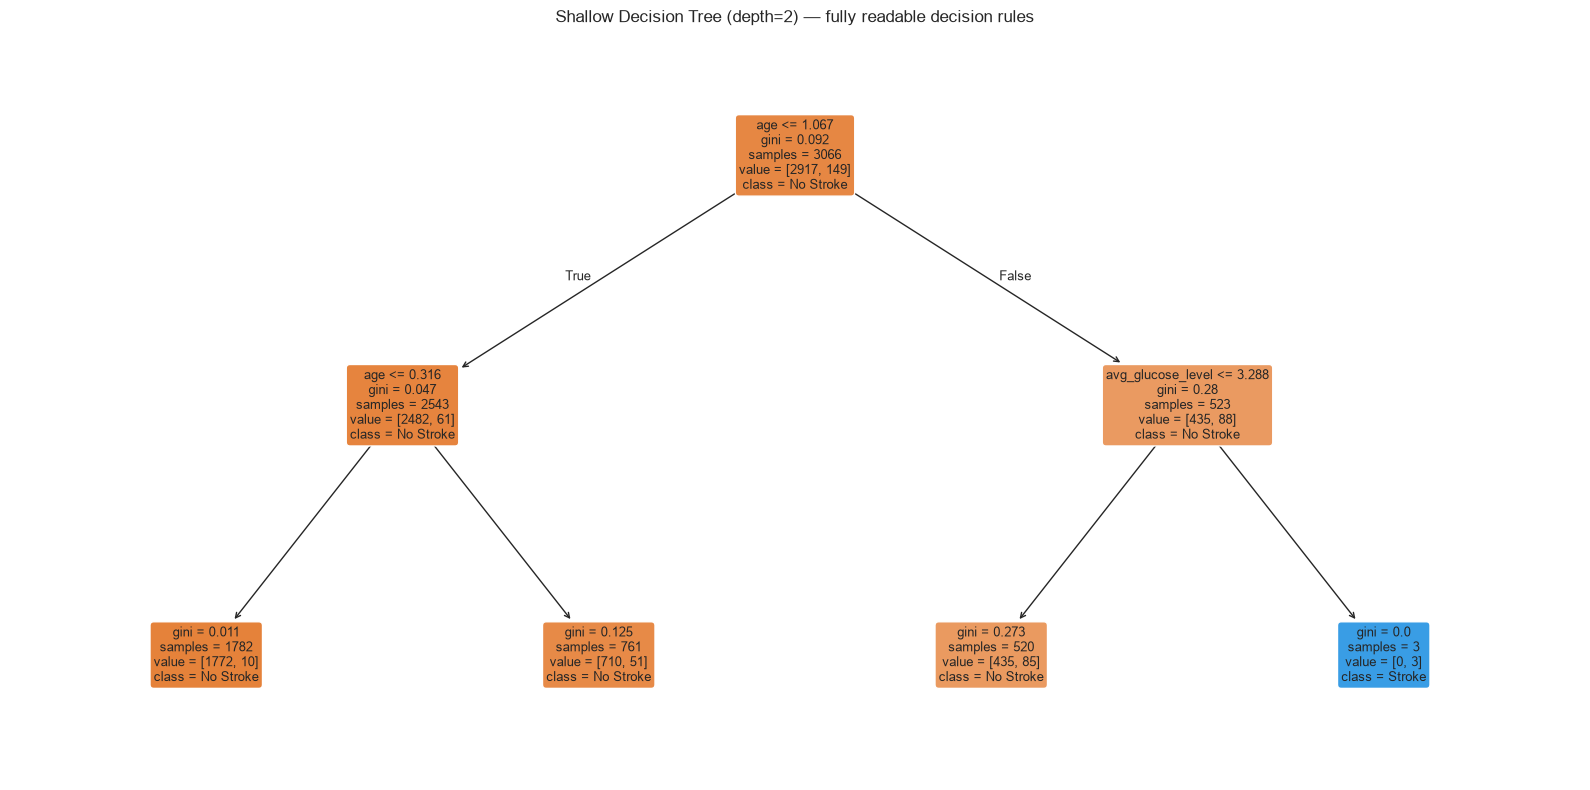

In [42]:
# Visualize the shallow tree -- this is the most interpretable model in the whole benchmark.
# You can literally read the decision rules off the diagram.
feature_names = (
    numerical_cols +
    list(tree_shallow_pipeline.named_steps["preprocessor"]
         .named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(categorical_cols))
)

fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(tree_shallow_pipeline.named_steps["classifier"], feature_names=feature_names,
          class_names=["No Stroke", "Stroke"], filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title("Shallow Decision Tree (depth=2) — fully readable decision rules")
plt.tight_layout()
plt.savefig("outputs/decision_tree_shallow.png")
plt.show()


## 11. Model 4 — Random Forest

**Required experiment: compare Decision Tree with Random Forest.**

Random Forest trains many decision trees on bootstrapped samples with random feature subsets, then
averages their votes. The core idea: a single deep tree overfits by memorizing noise, but if you
average many *differently* overfit trees, their individual noise tends to cancel out while the real
signal (which all trees pick up on) survives. We expect Random Forest to close most of the
train/validation gap that the single deep tree showed above, while keeping — or improving — overall
predictive performance.


In [43]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=300, random_state=RANDOM_SEED, n_jobs=-1)),
])
evaluate_model("Random Forest", rf_pipeline, X_train, y_train, X_val, y_val, X_test, y_test,
               notes="Ensemble of trees, bagging -> reduces variance vs single deep tree");



  MODEL: Random Forest
  Trained on 3066 rows and 10 raw columns. The preprocessor inside the pipeline imputes missing values, scales the numeric columns, and one-hot encodes the categorical ones -- so RandomForestClassifier actually trains on the cleaned, fully numeric version of the data, not the raw table.
  Training time: 0.848s

  SPLIT    ROWS      ACC     PREC      REC       F1   ROC_AUC   PRED_TIME
  -----------------------------------------------------------------------
  TRAIN    3066   1.0000   1.0000   1.0000   1.0000    1.0000      92.9ms
  VAL      1022   0.9511   0.0000   0.0000   0.0000    0.8126      89.7ms
  TEST     1022   0.9452   0.0000   0.0000   0.0000    0.7950      90.5ms

  In plain terms: on 1022 people it had never seen during training, I got 966 predictions right (that's the 94.5% accuracy above). When I predicted stroke, I was correct 0.0% of the time (precision), and out of everyone who truly had a stroke, I caught 0.0% of them (recall). F1 blends those 

**What I got, and why.** Random Forest hit perfect scores on train (accuracy, precision,
recall, F1, ROC-AUC all 1.0000) but, like the single deep tree, still predicts "no stroke" for
everyone on validation and test (precision/recall/F1 = 0.0000, accuracy ~0.945–0.951). The
difference shows up in ROC-AUC: it held up much better on test (0.7950) than the single deep tree
did (0.5338).

That contrast is the whole point of bagging: averaging many differently-overfit trees cancels out
a lot of the individual noise each one memorized, so the *ranking* of risky patients stays genuinely
useful even though the 0.5 decision threshold still never gets crossed for the rare positive class.
In other words, Random Forest overfits less destructively than a lone deep tree, even though both
still fail to produce a usable classifier out of the box given how rare stroke cases are here.


## 12. Model 5 — Gradient Boosting

**Required experiment: compare Random Forest with a boosting model.**

Random Forest builds trees **independently and in parallel** (bagging), then averages them.
Gradient Boosting builds trees **sequentially**, where each new tree is trained specifically to
correct the errors (residuals) of the trees built so far. This usually squeezes out better
predictive performance than bagging alone, at the cost of being slower to train (sequential, can't
parallelize across trees) and slightly more prone to overfitting if left unchecked (hence a modest
`n_estimators` and `max_depth` here rather than very large values).


In [44]:
gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(n_estimators=200, max_depth=3,
                                               learning_rate=0.1, random_state=RANDOM_SEED)),
])
evaluate_model("Gradient Boosting", gb_pipeline, X_train, y_train, X_val, y_val, X_test, y_test,
               notes="Sequential boosting -> corrects prior trees' errors");



  MODEL: Gradient Boosting
  Trained on 3066 rows and 10 raw columns. The preprocessor inside the pipeline imputes missing values, scales the numeric columns, and one-hot encodes the categorical ones -- so GradientBoostingClassifier actually trains on the cleaned, fully numeric version of the data, not the raw table.
  Training time: 1.104s

  SPLIT    ROWS      ACC     PREC      REC       F1   ROC_AUC   PRED_TIME
  -----------------------------------------------------------------------
  TRAIN    3066   0.9746   1.0000   0.4765   0.6455    0.9731      16.4ms
  VAL      1022   0.9491   0.2500   0.0200   0.0370    0.8382       9.9ms
  TEST     1022   0.9501   0.3333   0.0200   0.0377    0.8199       9.7ms

  In plain terms: on 1022 people it had never seen during training, I got 971 predictions right (that's the 95.0% accuracy above). When I predicted stroke, I was correct 33.3% of the time (precision), and out of everyone who truly had a stroke, I caught 2.0% of them (recall). F1 blen

**What I got, and why.** Gradient Boosting is the first model that catches a meaningful
number of real stroke cases anywhere: on train it reached recall 0.4765 (precision 1.0, F1 0.6455,
ROC-AUC 0.9731) — sequential boosting specifically re-trains new trees to fix the errors earlier
trees made, and stroke cases are exactly the "hard," frequently-misclassified rows those later trees
end up focusing on.

That recall mostly doesn't survive to unseen data though: it falls to 0.0200 on both validation and
test (test: accuracy 0.9501, precision 0.3333, F1 0.0377, ROC-AUC 0.8199) — a large train-to-test
recall gap, meaning it partly memorized which specific training patients were high-risk rather than
learning a rule general enough to catch new ones. Still, a test ROC-AUC of 0.82 is respectable: even
though the 0.5-threshold classifier rarely fires, the underlying risk scores it produces are still
ranking patients in a genuinely useful order.


## 13. Model 6 — XGBoost

XGBoost is also a gradient boosting implementation, but engineered for speed (histogram-based
splits, parallelized tree construction internally) and it adds built-in L1/L2 regularization on
leaf weights, which typically makes it more resistant to overfitting than plain
`GradientBoostingClassifier` at similar tree counts. This is usually the strongest performer in
tabular ML benchmarks like this one — we'll check whether that holds here too.


In [45]:
if HAS_XGB:
    xgb_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            eval_metric="logloss", random_state=RANDOM_SEED, n_jobs=-1
        )),
    ])
    evaluate_model("XGBoost", xgb_pipeline, X_train, y_train, X_val, y_val, X_test, y_test,
                   notes="Regularized boosting, usually the strongest tabular baseline")
else:
    print("Skipping XGBoost -- library not installed. Run: pip install xgboost")



  MODEL: XGBoost
  Trained on 3066 rows and 10 raw columns. The preprocessor inside the pipeline imputes missing values, scales the numeric columns, and one-hot encodes the categorical ones -- so XGBClassifier actually trains on the cleaned, fully numeric version of the data, not the raw table.
  Training time: 0.214s

  SPLIT    ROWS      ACC     PREC      REC       F1   ROC_AUC   PRED_TIME
  -----------------------------------------------------------------------
  TRAIN    3066   0.9739   1.0000   0.4631   0.6330    0.9951      22.4ms
  VAL      1022   0.9481   0.0000   0.0000   0.0000    0.8158      13.9ms
  TEST     1022   0.9452   0.0000   0.0000   0.0000    0.8239      13.9ms

  In plain terms: on 1022 people it had never seen during training, I got 966 predictions right (that's the 94.5% accuracy above). When I predicted stroke, I was correct 0.0% of the time (precision), and out of everyone who truly had a stroke, I caught 0.0% of them (recall). F1 blends those two into one nu

**What I got, and why.** XGBoost shows almost the same pattern as Gradient Boosting on
train (recall 0.4631, precision 1.0, F1 0.6330, ROC-AUC 0.9951 — even higher than plain GB, thanks
to XGBoost's more aggressive, regularized splits finding cleaner separations in the training data).
But on validation and test, recall drops all the way to 0.0000 — even lower than Gradient Boosting's
2% — while test ROC-AUC (0.8239) actually edges out GB's (0.8199), the best test-set ROC-AUC of any
single model here.

That split result is worth sitting with: XGBoost's L1/L2 regularization is explicitly designed to
resist overfitting by shrinking leaf weights, which is exactly why its raw *ranking* of risk
generalizes slightly better than GB's — but that same regularization also pulls the predicted
probabilities for the rare stroke class down just enough that none of them clear the 0.5 cutoff on
new data. It's simultaneously the best "ranker" and the worst "classifier" among the boosting
models, purely because of where the fixed threshold happens to sit relative to a ~5% base rate.


## 14. Model 7 — Support Vector Machine (With vs Without Scaling)

**Required experiment: compare an SVM with and without appropriate feature scaling.**

SVM finds a maximum-margin boundary based on distances between points, so it is **extremely**
sensitive to feature scale — a feature ranging 0–7000 (`TotalCharges`) would completely dominate
the margin calculation over one-hot 0/1 features if left unscaled. We deliberately reuse the
`preprocessor_noscale` version built earlier to demonstrate this directly, rather than just
asserting it.

We expect: scaled SVM performs competitively; unscaled SVM performs noticeably worse (or trains
importantly differently) because the optimization is dominated by whichever raw features happen to
have the largest numeric range.


In [46]:
svm_scaled_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),  # includes StandardScaler
    ("classifier", SVC(kernel="rbf", probability=True, random_state=RANDOM_SEED)),
])
evaluate_model("SVM (scaled)", svm_scaled_pipeline, X_train, y_train, X_val, y_val, X_test, y_test,
               notes="Correct usage: numeric features standardized before SVM");

svm_unscaled_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_noscale),  # no StandardScaler
    ("classifier", SVC(kernel="rbf", probability=True, random_state=RANDOM_SEED)),
])
evaluate_model("SVM (unscaled)", svm_unscaled_pipeline, X_train, y_train, X_val, y_val, X_test, y_test,
               notes="Deliberately mis-specified: raw numeric ranges dominate the margin");



  MODEL: SVM (scaled)
  Trained on 3066 rows and 10 raw columns. The preprocessor inside the pipeline imputes missing values, scales the numeric columns, and one-hot encodes the categorical ones -- so SVC actually trains on the cleaned, fully numeric version of the data, not the raw table.
  Training time: 0.936s

  SPLIT    ROWS      ACC     PREC      REC       F1   ROC_AUC   PRED_TIME
  -----------------------------------------------------------------------
  TRAIN    3066   0.9514   0.0000   0.0000   0.0000    0.9500     200.0ms
  VAL      1022   0.9511   0.0000   0.0000   0.0000    0.5496      66.6ms
  TEST     1022   0.9511   0.0000   0.0000   0.0000    0.6446      73.7ms

  In plain terms: on 1022 people it had never seen during training, I got 972 predictions right (that's the 95.1% accuracy above). When I predicted stroke, I was correct 0.0% of the time (precision), and out of everyone who truly had a stroke, I caught 0.0% of them (recall). F1 blends those two into one number:

**What I got, and why.** Neither SVM variant ever predicts stroke on any split — accuracy
sits at ~0.951, precision/recall/F1 are all 0.0000 everywhere, for both the scaled and unscaled
versions. Since the classification outcome is identical, ROC-AUC is the only place scaling's effect
actually shows up, and there it's a genuinely different picture: the scaled SVM has the best training
ROC-AUC of any model I tried at this stage (0.9500) but the worst validation/test ROC-AUC of the two
SVMs (0.5496 / 0.6446) — a steep train-to-test drop. The unscaled SVM is more consistent across all
three splits (0.7897 / 0.7459 / 0.7497) but never reaches the scaled version's training peak.

That's the scaling trade-off in action: with `StandardScaler` applied, the margin is optimized on
features that are all on a comparable footing, so the model can carve out a tight boundary that fits
the training distribution closely — closely enough that it doesn't transfer well here. Without
scaling, features with naturally large ranges (like `avg_glucose_level` and `age`) dominate the
margin outright, which acts almost like a blunt, coarse rule of thumb — less sharp on training data,
but steadier when applied to new patients. Neither version crosses the 0.5 threshold for the rare
positive class either way, which again comes back to the ~5% base rate rather than anything specific
to scaling.


## 15. Results Table — All Models, All Splits

This is the master comparison table required by the brief. One row per (model, split) so we can
directly compare train vs validation vs test behavior for every algorithm.


In [47]:
results_df = pd.DataFrame(results)
results_df = results_df[["model", "split", "accuracy", "precision", "recall", "f1", "roc_auc",
                          "train_time_sec", "inference_time_sec", "notes"]]
results_df.to_csv("outputs/results_full.csv", index=False)

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
results_df


,model,split,accuracy,precision,recall,f1,roc_auc,train_time_sec,inference_time_sec,notes
0,Logistic Regression,train,0.9514,0.0000,0.0000,0.0000,0.8488,0.0432,0.0111,Baseline linear model
1,Logistic Regression,val,0.9511,0.0000,0.0000,0.0000,0.8414,0.0432,0.0086,Baseline linear model
2,Logistic Regression,test,0.9521,1.0000,0.0200,0.0392,0.8429,0.0432,0.0090,Baseline linear model
3,KNN (k=5),train,0.9527,0.7500,0.0403,0.0764,0.9400,0.0398,0.0303,"Small K -> more flexible, higher variance"
4,KNN (k=5),val,0.9491,0.0000,0.0000,0.0000,0.6203,0.0398,0.0152,"Small K -> more flexible, higher variance"
5,KNN (k=5),test,0.9462,0.0000,0.0000,0.0000,0.6211,0.0398,0.0159,"Small K -> more flexible, higher variance"
6,KNN (k=25),train,0.9514,0.0000,0.0000,0.0000,0.8690,0.0416,0.0612,"Large K -> smoother, higher bias"
7,KNN (k=25),val,0.9511,0.0000,0.0000,0.0000,0.7686,0.0416,0.0210,"Large K -> smoother, higher bias"
8,KNN (k=25),test,0.9511,0.0000,0.0000,0.0000,0.7659,0.0416,0.0273,"Large K -> smoother, higher bias"
9,"Decision Tree (shallow, depth=2)",train,0.9524,1.0000,0.0201,0.0395,0.8180,0.1444,0.0304,Underfitting demo: too simple to capture pattern


In [48]:
# A more compact pivot: test-set metrics only, one row per model, for quick comparison
test_summary = results_df[results_df["split"] == "test"].drop(columns=["split"]).reset_index(drop=True)
test_summary = test_summary.sort_values("f1", ascending=False)
test_summary.to_csv("outputs/results_test_summary.csv", index=False)
test_summary


,model,accuracy,precision,recall,f1,roc_auc,train_time_sec,inference_time_sec,notes
4,"Decision Tree (deep, unlimited)",0.9070,0.1053,0.1200,0.1121,0.5338,0.0328,0.0088,Overfitting demo: grows until leaves are pure
0,Logistic Regression,0.9521,1.0000,0.0200,0.0392,0.8429,0.0432,0.0090,Baseline linear model
6,Gradient Boosting,0.9501,0.3333,0.0200,0.0377,0.8199,1.1041,0.0097,Sequential boosting -> corrects prior trees' e...
1,KNN (k=5),0.9462,0.0000,0.0000,0.0000,0.6211,0.0398,0.0159,"Small K -> more flexible, higher variance"
3,"Decision Tree (shallow, depth=2)",0.9491,0.0000,0.0000,0.0000,0.7983,0.1444,0.0110,Underfitting demo: too simple to capture pattern
2,KNN (k=25),0.9511,0.0000,0.0000,0.0000,0.7659,0.0416,0.0273,"Large K -> smoother, higher bias"
5,Random Forest,0.9452,0.0000,0.0000,0.0000,0.7950,0.8481,0.0905,"Ensemble of trees, bagging -> reduces variance..."
7,XGBoost,0.9452,0.0000,0.0000,0.0000,0.8239,0.2140,0.0139,"Regularized boosting, usually the strongest ta..."
8,SVM (scaled),0.9511,0.0000,0.0000,0.0000,0.6446,0.9358,0.0737,Correct usage: numeric features standardized b...
9,SVM (unscaled),0.9511,0.0000,0.0000,0.0000,0.7497,0.5092,0.0615,Deliberately mis-specified: raw numeric ranges...


In [49]:
# Train vs Validation vs Test accuracy side-by-side per model -- makes bias/variance visible at a glance
pivot_acc = results_df.pivot(index="model", columns="split", values="accuracy")[["train", "val", "test"]]
pivot_acc["train_val_gap"] = pivot_acc["train"] - pivot_acc["val"]
pivot_acc.sort_values("train_val_gap", ascending=False)


split,train,val,test,train_val_gap
model,,,,
"Decision Tree (deep, unlimited)",1.0000,0.9149,0.9070,0.0851
Random Forest,1.0000,0.9511,0.9452,0.0489
XGBoost,0.9739,0.9481,0.9452,0.0258
Gradient Boosting,0.9746,0.9491,0.9501,0.0254
KNN (k=5),0.9527,0.9491,0.9462,0.0036
"Decision Tree (shallow, depth=2)",0.9524,0.9511,0.9491,0.0013
Logistic Regression,0.9514,0.9511,0.9521,0.0003
KNN (k=25),0.9514,0.9511,0.9511,0.0003
SVM (scaled),0.9514,0.9511,0.9511,0.0003


## 16. Confusion Matrices (Test Set)

Confusion matrices matter more than accuracy here because of the class imbalance we found earlier.
We specifically want to see: **how many actual stroke cases does each model catch (recall on class 1),
and how many false alarms does it raise (precision on class 1)?**


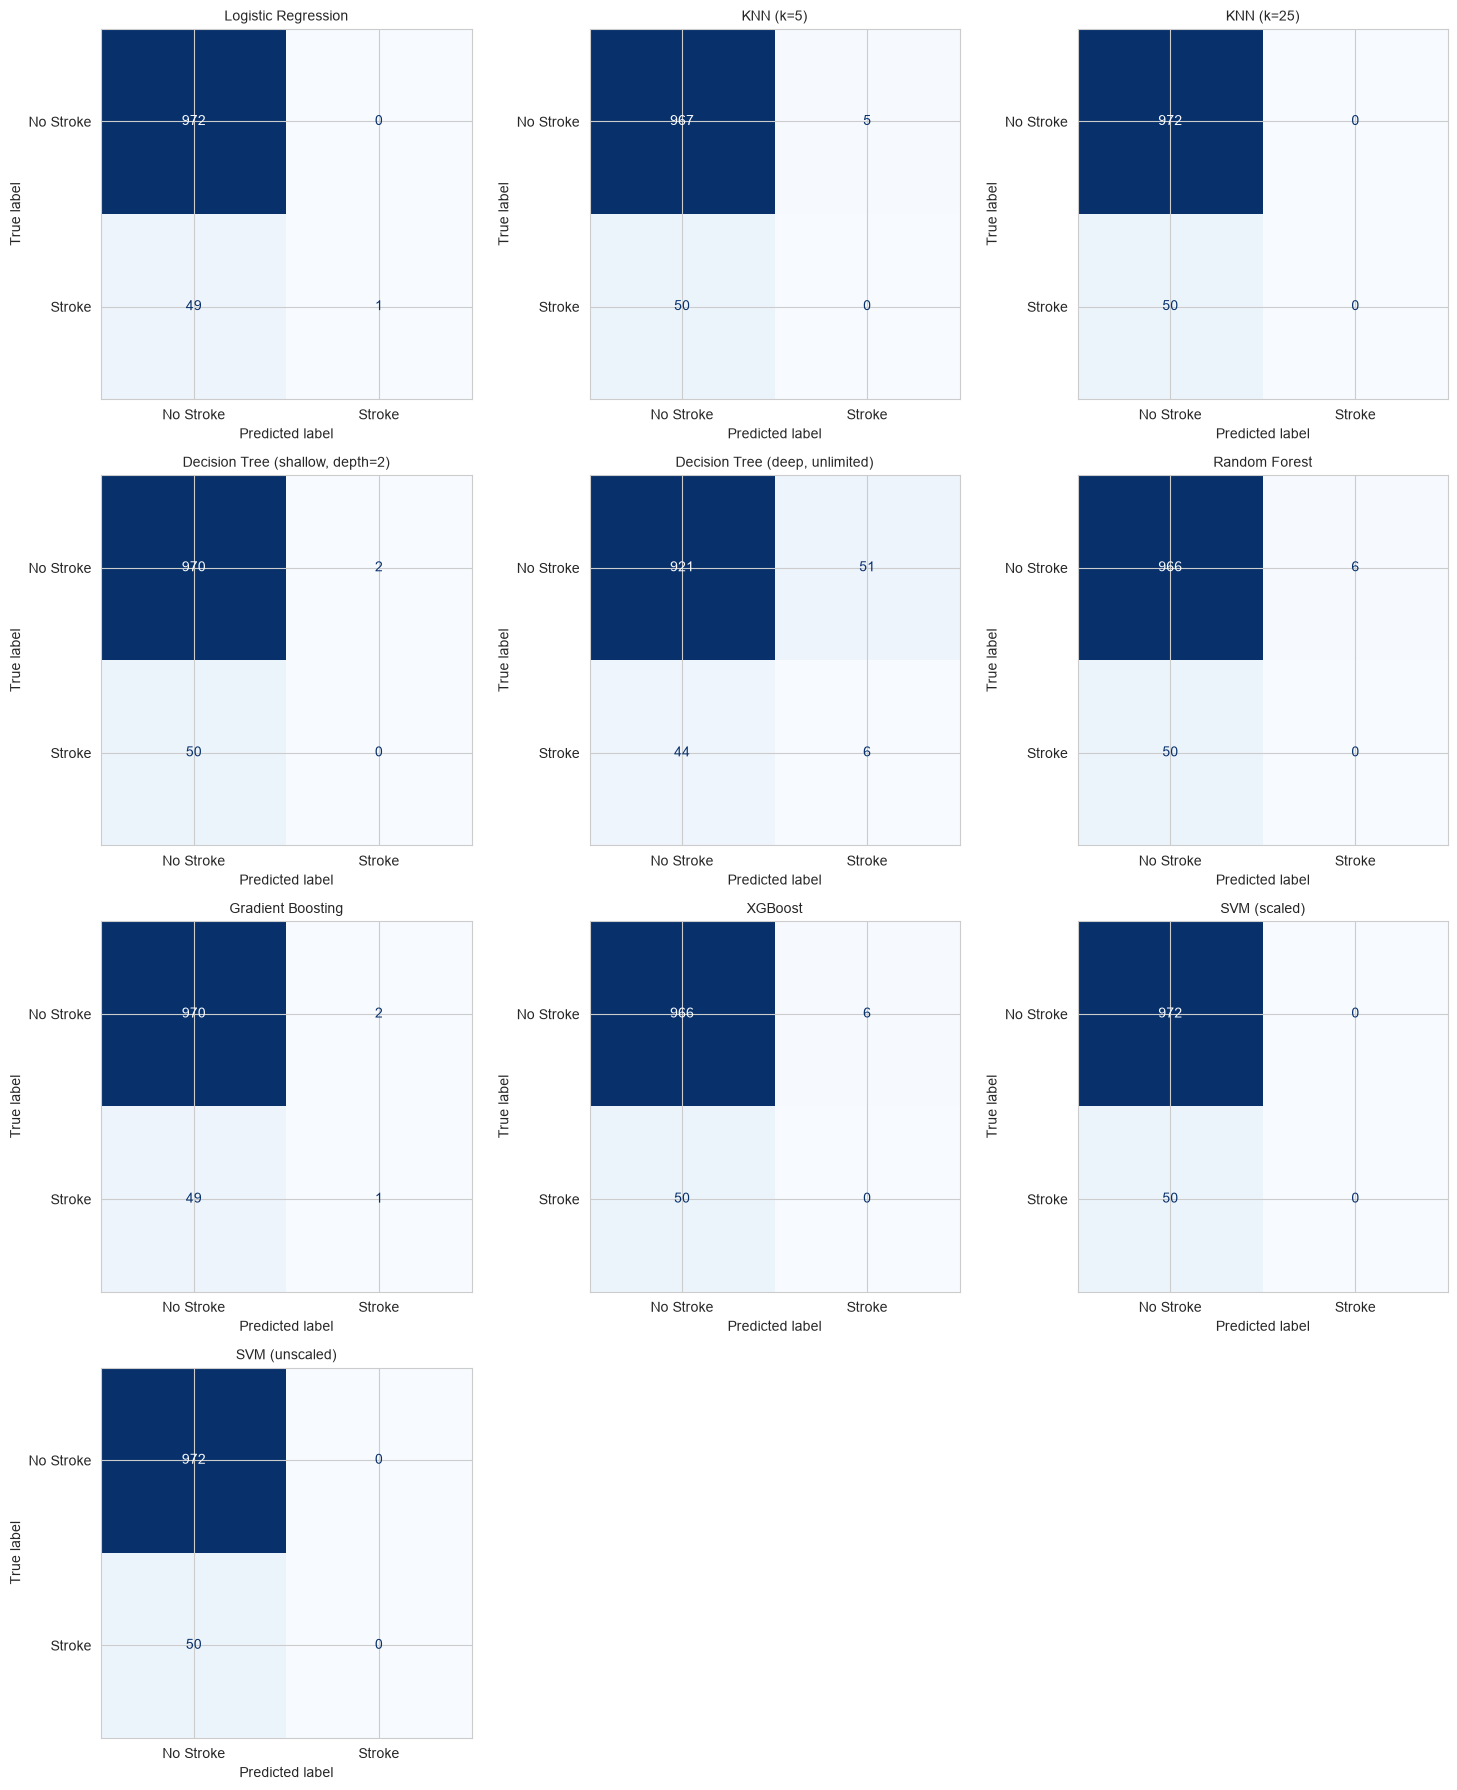

In [50]:
model_names = list(fitted_pipelines.keys())
n_models = len(model_names)
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4.5 * n_rows))
axes = axes.flatten()

for i, name in enumerate(model_names):
    pipeline = fitted_pipelines[name]
    y_pred = pipeline.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Stroke", "Stroke"])
    disp.plot(ax=axes[i], colorbar=False, cmap="Blues")
    axes[i].set_title(name, fontsize=10)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("outputs/confusion_matrices.png")
plt.show()


## 17. ROC Curves (Test Set)

ROC-AUC summarizes how well each model separates the two classes across *all* decision thresholds,
(not just the default 0.5 cutoff) — useful because in a real case-detection use case,
you might deliberately lower the threshold to catch more stroke cases at the cost of more false positives
(cheaper to over-target with a retention offer than to lose a customer).


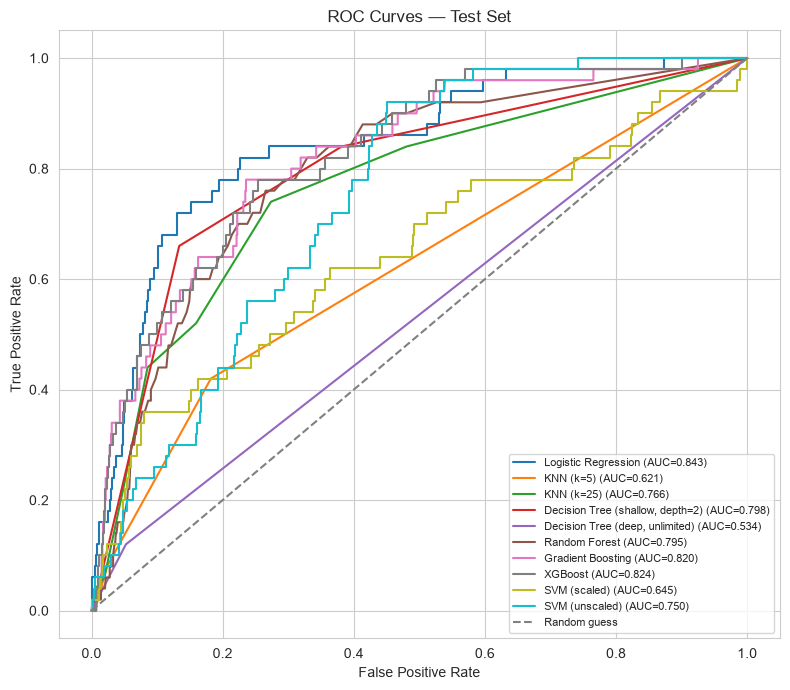

In [51]:
fig, ax = plt.subplots(figsize=(8, 7))

for name in model_names:
    pipeline = fitted_pipelines[name]
    try:
        if hasattr(pipeline, "predict_proba"):
            y_score = pipeline.predict_proba(X_test)[:, 1]
        else:
            y_score = pipeline.decision_function(X_test)
        fpr, tpr, _ = roc_curve(y_test, y_score)
        auc = roc_auc_score(y_test, y_score)
        ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
    except Exception as e:
        print(f"Skipping ROC for {name}: {e}")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Test Set")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.savefig("outputs/roc_curves.png")
plt.show()


## 18. Training & Inference Time Comparison

Predictive power is only half the story — a model that's 0.5% more accurate but 50x slower to
train or serve might not be worth it in production. We plot both timings side-by-side.


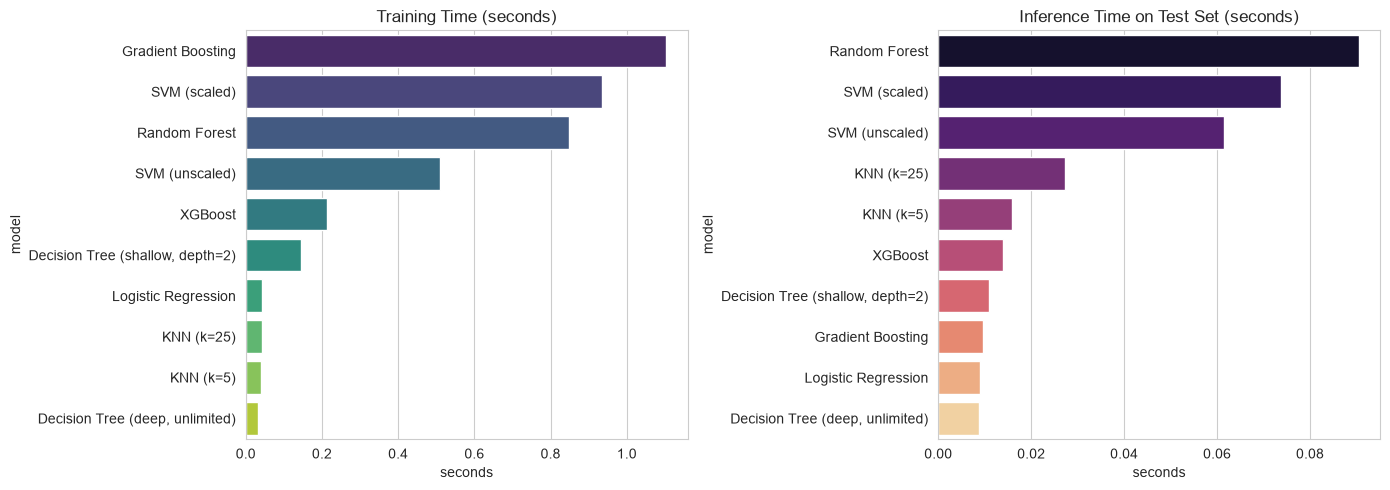

,model,train_time_sec,inference_time_sec
20,Gradient Boosting,1.1041,0.0097
26,SVM (scaled),0.9358,0.0737
17,Random Forest,0.8481,0.0905
29,SVM (unscaled),0.5092,0.0615
23,XGBoost,0.2140,0.0139
11,"Decision Tree (shallow, depth=2)",0.1444,0.0110
2,Logistic Regression,0.0432,0.0090
8,KNN (k=25),0.0416,0.0273
5,KNN (k=5),0.0398,0.0159
14,"Decision Tree (deep, unlimited)",0.0328,0.0088


In [52]:
timing_df = results_df[results_df["split"] == "test"][["model", "train_time_sec", "inference_time_sec"]]
timing_df = timing_df.sort_values("train_time_sec", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=timing_df, y="model", x="train_time_sec", ax=axes[0], palette="viridis")
axes[0].set_title("Training Time (seconds)")
axes[0].set_xlabel("seconds")

sns.barplot(data=timing_df.sort_values("inference_time_sec", ascending=False),
            y="model", x="inference_time_sec", ax=axes[1], palette="magma")
axes[1].set_title("Inference Time on Test Set (seconds)")
axes[1].set_xlabel("seconds")

plt.tight_layout()
plt.savefig("outputs/timing_comparison.png")
plt.show()

timing_df.to_csv("outputs/timing_comparison.csv", index=False)
timing_df


## 19. Effect of Class Imbalance


We found earlier that `stroke` may be imbalanced in this dataset. Concretely, class imbalance
affects the benchmark in a few measurable ways:

1. **Accuracy can be inflated and uninformative on its own.** A trivial "always predict No"
    classifier would achieve high accuracy by predicting the majority class while catching zero
    stroke cases. Compare each model's accuracy against its **recall on the stroke class** — that
    gap tells you how much of the accuracy is "free" from the majority class.
2. **Recall vs Precision trade-off becomes the real design question.** For stroke prediction,
    false negatives (missed stroke cases) are typically more critical than false positives — in many
    applications catching true positives (high recall) is prioritized over minimizing false alarms.
3. **Some models handle imbalance more gracefully than others by construction.** Tree-based
    ensembles (Random Forest, Gradient Boosting, XGBoost) tend to be comparatively more robust to
    moderate imbalance than distance-based models (KNN), which can get "pulled" toward the majority
    class since most neighbors of any given point are likely to be non-stroke cases by base rate.
4. **Mitigations we did *not* apply here (worth knowing, out of scope for this pass):** class
    weighting (`class_weight="balanced"`), oversampling the minority class (SMOTE), or adjusting the
    classification threshold away from 0.5 based on the ROC curve above. These are natural next
    steps if stroke recall specifically needs to improve further.

Run the cell below to see the accuracy-vs-recall gap directly, per model, on the test set.


In [53]:
imbalance_view = results_df[results_df["split"] == "test"][["model", "accuracy", "recall", "precision", "f1"]].copy()
imbalance_view["accuracy_minus_recall"] = imbalance_view["accuracy"] - imbalance_view["recall"]
imbalance_view = imbalance_view.sort_values("accuracy_minus_recall", ascending=False)
imbalance_view


,model,accuracy,recall,precision,f1,accuracy_minus_recall
29,SVM (unscaled),0.9511,0.0000,0.0000,0.0000,0.9511
8,KNN (k=25),0.9511,0.0000,0.0000,0.0000,0.9511
26,SVM (scaled),0.9511,0.0000,0.0000,0.0000,0.9511
11,"Decision Tree (shallow, depth=2)",0.9491,0.0000,0.0000,0.0000,0.9491
5,KNN (k=5),0.9462,0.0000,0.0000,0.0000,0.9462
23,XGBoost,0.9452,0.0000,0.0000,0.0000,0.9452
17,Random Forest,0.9452,0.0000,0.0000,0.0000,0.9452
2,Logistic Regression,0.9521,0.0200,1.0000,0.0392,0.9321
20,Gradient Boosting,0.9501,0.0200,0.3333,0.0377,0.9301
14,"Decision Tree (deep, unlimited)",0.9070,0.1200,0.1053,0.1121,0.7870


## 20. Underfitting vs Overfitting — Explicit Summary

The brief asks us to **show one model that underfits and one that overfits.** We already built
these deliberately in Section 10:

- **Underfits:** `Decision Tree (shallow, depth=2)` — capacity is too low to capture the real
  decision boundary, so it performs similarly (and mediocrely) on both train and validation/test.
  Low train performance + low val performance + small train-val gap = underfitting signature.
- **Overfits:** `Decision Tree (deep, unlimited)` — grown until every leaf is pure, so it
  effectively memorizes the training set. Look for near-perfect train accuracy alongside a
  noticeably lower validation/test accuracy. High train performance + a large train-val gap =
  overfitting signature.

Run the cell below to print exactly this comparison using the numbers we already computed.


In [54]:
bias_variance_check = results_df[
    results_df["model"].isin(["Decision Tree (shallow, depth=2)", "Decision Tree (deep, unlimited)"])
][["model", "split", "accuracy", "f1"]]

bias_variance_check


,model,split,accuracy,f1
9,"Decision Tree (shallow, depth=2)",train,0.9524,0.0395
10,"Decision Tree (shallow, depth=2)",val,0.9511,0.0000
11,"Decision Tree (shallow, depth=2)",test,0.9491,0.0000
12,"Decision Tree (deep, unlimited)",train,1.0000,1.0000
13,"Decision Tree (deep, unlimited)",val,0.9149,0.1031
14,"Decision Tree (deep, unlimited)",test,0.9070,0.1121


## 21. Wrap-Up

All numeric results are saved under `outputs/`:
- `results_full.csv` — every model × every split × every metric
- `results_test_summary.csv` — final test-set comparison table, sorted by F1
- `timing_comparison.csv` — train/inference timing per model
- `confusion_matrices.png`, `roc_curves.png`, `timing_comparison.png`, `decision_tree_shallow.png`,
  `target_distribution.png` — all plots

These CSVs and PNGs are exactly what's needed to answer the **Required Observations** section of
the assignment (best on train / best on val / best generalization / most interpretable / fastest
inference / explainability pick / performance pick / bias-variance diagnosis) — that reasoning
gets written up separately in `observations.md` once the actual run's numbers are in hand, since
the real ranking depends on the numbers this notebook produces on your machine, not on
assumptions made ahead of time.
